<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Trabalho em grupo - Modelo SARIMA <span style="color: #00a2ff;"></span>
    </h2>
    <hr style="border: 0; border-top: 1px solid #1e293b; margin: 10px 0;">
    <p">
        <b>Membros:</b> <span style="color: #b6e4fa ; font-size: 12px;">Gabriel Martins Oliveira | Leticia Nascimento da Silva | Theo Correia Martins | Vitor De Mello Maciel  </span> 
    </p>
    <p>
        <b>Matéria:</b> <span style="color: #b6e4fa ; font-size: 12px;">Séries Temporais</span>
    </p>
    <p>
        <b>Data Entrega:</b> <span style="color: #b6e4fa ; font-size: 12px;">22/05/2026</span> 
    </p>
</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
            background-color: #0a0e14; 
            color: #e0e6ed; 
            padding: 30px; 
            border: 1px solid #1e293b; 
            border-radius: 8px;
            line-height: 1.6;">

<div style="border-bottom: 2px solid #0078d4; padding-bottom: 15px; margin-bottom: 20px;">
        <h1 style="color: #00a2ff; margin: 0; font-size: 24px; letter-spacing: 2px; text-transform: uppercase;">
            <span style="color: #ffffff;"></span> Descrição do Projeto
        </h1>
    </div>

<div style="margin-bottom: 25px; background: rgba(0, 120, 212, 0.05); padding: 15px; border-left: 4px solid #0078d4;">
        <p style="margin-bottom: 0;">
            O objetivo deste trabalho é realizar a modelagem completa de uma <b>série temporal não estacionária</b>. Através de técnicas de diferenciação e análise estatística, buscaremos extrair padrões preditivos e validar a eficiência do modelo contra referências de mercado.
        </p>
    </div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-bottom: 25px;">
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Implementação Técnicas</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>Teste de Estacionariedade; </li>
                <li>Contrução de Pipeline Completa; </li>
                <li>Modelagem Comparativa (Base Models).</li>
            </ul>
        </div>
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Métricas de Validação</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>MAE (Mean Absolute Error) de Teste</li>
                <li>MAE (Rolling Forecast)</li>
                <li>Análise de Resíduos (Ruído Branco)</li>
            </ul>
        </div>
    </div>

<div style="background: #0f172a; padding: 10px; border-radius: 4px; font-family: monospace; font-size: 13px;">
        <span style="color: #00ff88;">[INFO]</span> Entregáveis: 
        <code style="color: #38bdf8; background: transparent;">Notebook.ipynb</code> & 
        <code style="color: #38bdf8; background: transparent;">Relatorio_Final.pdf</code>
    </div>

</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        01. Importações <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as importações necessárias nesse bloco de código.</span> 
    </p>   
</div>

In [22]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from IPython import display
from IPython.display import display
warnings.filterwarnings('ignore')

# Estatística / Modelagem
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL


# Métricas
from sklearn.metrics import mean_absolute_error


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        02. Funções Pipeline <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as funções necessárias nesses blocos de código.</span> 
    </p>   
</div>

In [23]:
def testa_estacionariedade(serie):
    resultado_adf = adfuller(serie.dropna())
    p_adf = resultado_adf[1]
    
    resultado_kpss = kpss(serie.dropna())
    p_kpss = resultado_kpss[1]
    
    print(f'ADF P-Value: {p_adf:.4f} | KPSS P-Value: {p_kpss:.4f}')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(serie.dropna(), lags=40, ax=ax, title="Função de Autocorrelação (ACF)")
    plt.show()
    
    # Estacionária se ADF <= 0.05 e KPSS > 0.05
    if p_adf <= 0.05 and p_kpss > 0.05:
        print("=> A série é ESTACIONÁRIA.")
        return True
    elif p_adf > 0.05 and p_kpss <= 0.05:
        print("=> A série NÃO É ESTACIONÁRIA.")
        return False
    else:
        print("=> Inconclusivo / Estacionária por partes. Assumindo NÃO ESTACIONÁRIA por segurança.")
        return False

def reverte_diferenciacao(previsoes_diff, serie_original_treino, ordem_diff):
    if ordem_diff == 0:
        return previsoes_diff

    if ordem_diff == 1:
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_diff.cumsum()
        return previsoes_escala_original

    elif ordem_diff == 2:
        primeira_diff_treino = serie_original_treino.diff().dropna()
        ultimo_valor_primeira_diff = primeira_diff_treino.iloc[-1]
        
        previsoes_1a_diff = ultimo_valor_primeira_diff + previsoes_diff.cumsum()
        
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_1a_diff.cumsum()
        return previsoes_escala_original        

def torna_estacionaria(serie, nome="Série"):
    print(f"\n--- Analisando: {nome} ---")
    plt.plot(serie.values, color='blue')
    plt.title(f'Série Original - {nome}')
    plt.show()
    
    serie_diff = serie.copy()
    ordem = 0
    
    while not testa_estacionariedade(serie_diff) and ordem < 2:
        serie_diff = serie_diff.diff().dropna()
        ordem += 1
        print(f"\nx Aplicada diferenciação de ordem {ordem}")
        
        plt.plot(serie_diff.values, color='green')
        plt.title(f'Série Diferenciada (Ordem {ordem}) - {nome}')
        plt.show()
        
    return serie_diff, ordem


In [24]:
def melhor_m_stl(serie, max_m):
    serie = serie.dropna()
    melhor_m = None
    melhor_forca = -np.inf
    resultados = []

    for m_candidate in range(2, max_m + 1):
        stl_result = STL(serie, period=m_candidate, robust=True).fit()
        denom = np.var(stl_result.seasonal + stl_result.resid)
        if denom == 0:
            forca = 0.0
        else:
            forca = 1 - (np.var(stl_result.resid) / denom)

        resultados.append((m_candidate, forca))

        if forca > melhor_forca:
            melhor_forca = forca
            melhor_m = m_candidate

    print("Avaliação de candidatos:")
    for m_candidate, forca in resultados:
        print(f"m = {m_candidate:2d} -> Força de sazonalidade: {forca:.4f}")

    print(f"\nMelhor m escolhido: {melhor_m} (força de sazonalidade = {melhor_forca:.4f})")

    stl_best = STL(serie, period=melhor_m, robust=True).fit()
    fig = stl_best.plot()
    fig.set_size_inches(20, 10)
    plt.tight_layout()
    plt.show()

    print(f"Força de sazonalidade (0-1): {melhor_forca: .4f}")
    return melhor_m

In [25]:
def testa_sarima(order, seasonal_order, y):
   model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
   model_fit = model.fit(disp=False, maxiter=100)
   return model_fit


def busca_melhor_sarima(y, p_range, d_range, q_range, P_range, D_range, Q_range, m):
   resultados = []
   melhor_bic = float('inf')
   melhor_ordem = None
   melhor_seasonal = None
   melhor_modelo = None

   for p in p_range:
      for d in d_range:
         for q in q_range:
            for P in P_range:
               for D in D_range:
                  for Q in Q_range:
                     ordem = (p, d, q)
                     seasonal_ordem = (P, D, Q, m)
                     try:
                        resultado = testa_sarima(ordem, seasonal_ordem, y)
                        bic = float(resultado.bic)
                        resultados.append({
                           'order': ordem,
                           'seasonal_order': seasonal_ordem,
                           'bic': bic
                        })
   
                        if bic < melhor_bic:
                           melhor_bic = bic
                           melhor_ordem = ordem
                           melhor_seasonal = seasonal_ordem
                           melhor_modelo = resultado
                     except Exception:
                        pass

   tabela = pd.DataFrame(resultados)
   tabela = tabela.sort_values('bic').reset_index(drop=True)
   print(f"Melhor por BIC: {melhor_ordem} x {melhor_seasonal} | BIC = {melhor_bic:.2f}")
   return tabela, melhor_modelo, melhor_ordem, melhor_seasonal

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        03. Carregamento e Entendimento da Base <span style="color: #00a2ff;"></span>
    </h2>
    <p>
        <span style="color: #b6e4fa ; font-size: 16px;">Carregar a base de dados do S&P 500, realizar a agregação semanal e verificar a consistência dos dados.</span> 
    </p>   
</div>


In [27]:
df = pd.read_csv('naoEstacionaria\\vendas_sazonal.csv')

COLUNA_DATA = 'data'
COLUNA_VALOR = 'vendas'

# Limpeza e conversão
# df = df.drop(columns=['Open', 'Low', 'Close', 'Volume'], errors='ignore')
df[COLUNA_DATA] = pd.to_datetime(df[COLUNA_DATA])
df = df.sort_values(COLUNA_DATA)
df.set_index(COLUNA_DATA, inplace=True)

# Agrupamos semanalmente pela média do valor Vendas para reduzir o ruído
df_weekly = df[[COLUNA_VALOR]].resample('W').mean()

nulos = df_weekly.isnull().sum()
print("Valores nulos por coluna na base semanal:")
print(nulos)

if nulos.sum() > 0:
    df_weekly = df_weekly.interpolate(method='linear')
    print("x Valores nulos preenchidos via interpolação linear.")

display(df_weekly.head())
print("\nEstatísticas descritivas da base semanal:")
display(df_weekly.describe())


Valores nulos por coluna na base semanal:
vendas    0
dtype: int64


,vendas
data,
2024-01-07,113.633264
2024-01-14,105.532278
2024-01-21,116.687490
2024-01-28,102.613953
2024-02-04,101.323908



Estatísticas descritivas da base semanal:


,vendas
count,105.000000
mean,100.105423
std,11.693322
min,77.391066
25%,90.043301
50%,100.036673
75%,110.187628
max,122.417010


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        04. Análise de Estacionaridade <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;"> Após o carregamento das bases, vamos entender comportamento e em qual classficação ela se encaixa.</span> 
    </p>
    <p>
        <span style=" color: #00a2ff"> Estácionária</span>
    </p>
    <p>
        <span style=" color: #00a2ff"> Não Estácionária</span>
    </p>
</div>

### Análise Visual e Decomposição STL

Plota o gráfico temporal da série semanal e realiza a decomposição STL com o período sazonal de 52 semanas.


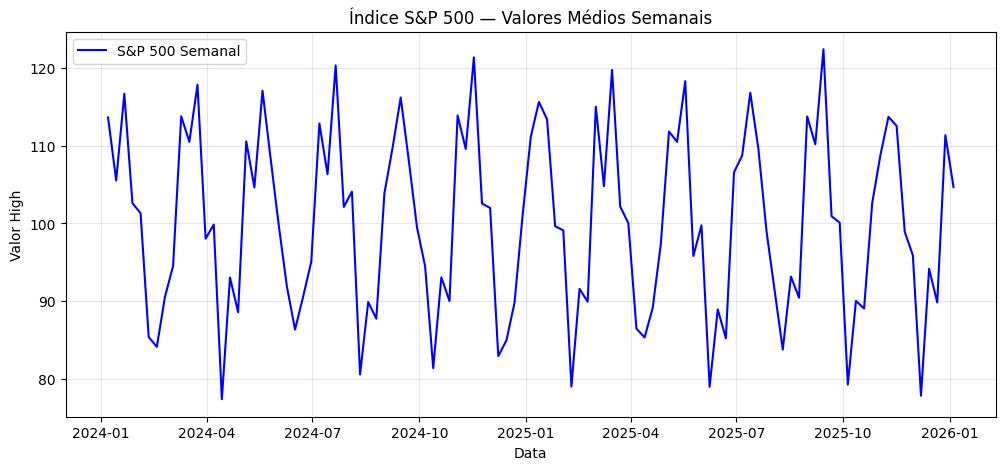

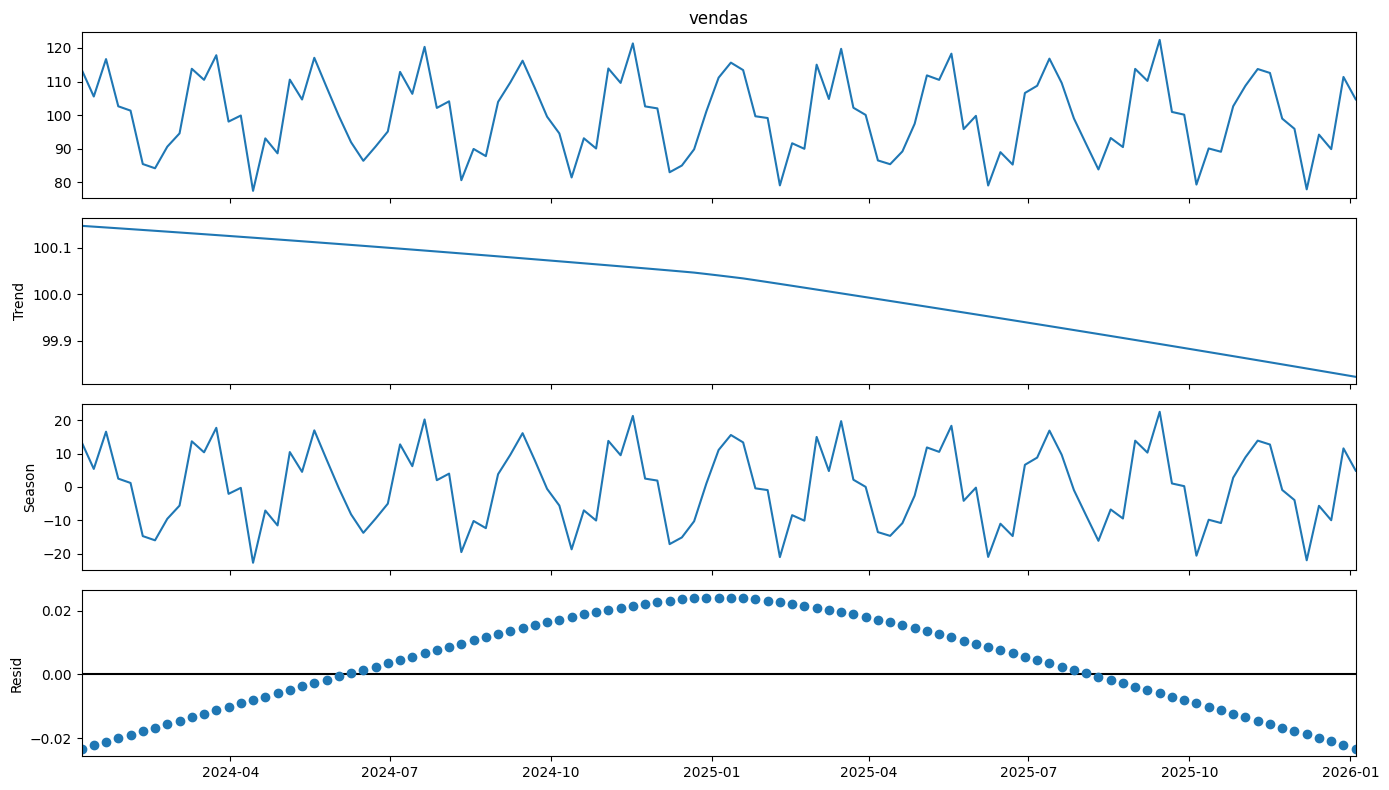

In [28]:
# Plot da série temporal semanal
plt.figure(figsize=(12, 5))
plt.plot(df_weekly.index, df_weekly[COLUNA_VALOR].values, color='blue', label='S&P 500 Semanal')
plt.title('Índice S&P 500 — Valores Médios Semanais')
plt.xlabel('Data')
plt.ylabel('Valor High')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Decomposição STL (período de 52 semanas para sazonalidade anual)
m_stl = 52
stl_result = STL(df_weekly[COLUNA_VALOR], period=m_stl, robust=True).fit()

# Plot da Decomposição
fig = stl_result.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


### Cálculo da Força da Sazonalidade

Calcula numericamente as métricas de força da sazonalidade e da tendência com base nos resíduos do STL.


In [29]:
forca_saz, forca_trend = calcula_forca_sazonalidade(stl_result)

print("\n--- Análise da Força Sazonal ---")
if forca_saz > 0.3:
    print(f"Força da Sazonalidade: {forca_saz:.4f} (> 0.30).")
    print("A sazonalidade da série semanal é RELEVANTE. Isso justifica fortemente o uso do modelo sazonal SARIMA.")
else:
    print(f"Força da Sazonalidade: {forca_saz:.4f} (<= 0.30).")
    print("A sazonalidade da série semanal é considerada fraca. Modelos ARIMA tradicionais seriam viáveis, mas o SARIMA é mantido para validação robusta.")


NameError: name 'calcula_forca_sazonalidade' is not defined

### Testes de Estacionariedade (ADF & KPSS)

Executa os testes ADF e KPSS na série semanal original para determinar o grau de diferenciação necessário para torná-la estacionária.


--- Diagnóstico de Estacionariedade da Série Original ---

--- Analisando: S&P 500 Semanal ---


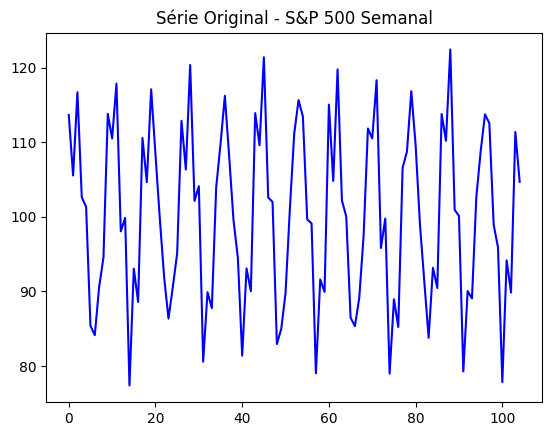

ADF P-Value: 0.0275 | KPSS P-Value: 0.1000


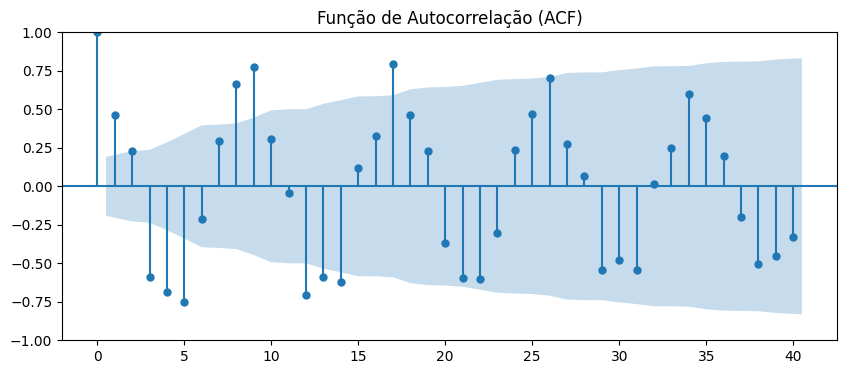

=> A série é ESTACIONÁRIA.

Ordem de diferenciação (d) final sugerida: 0


In [30]:
print("--- Diagnóstico de Estacionariedade da Série Original ---")
# testa_estacionariedade(df_weekly[COLUNA_VALOR])

serie_diff, ordem_diff = torna_estacionaria(df_weekly[COLUNA_VALOR], nome="S&P 500 Semanal")
print(f"\nOrdem de diferenciação (d) final sugerida: {ordem_diff}")


### Análise de ACF e PACF da Série Diferenciada

Gera as autocorrelações lineares para apoiar a seleção inicial de parâmetros p, q, P, Q.


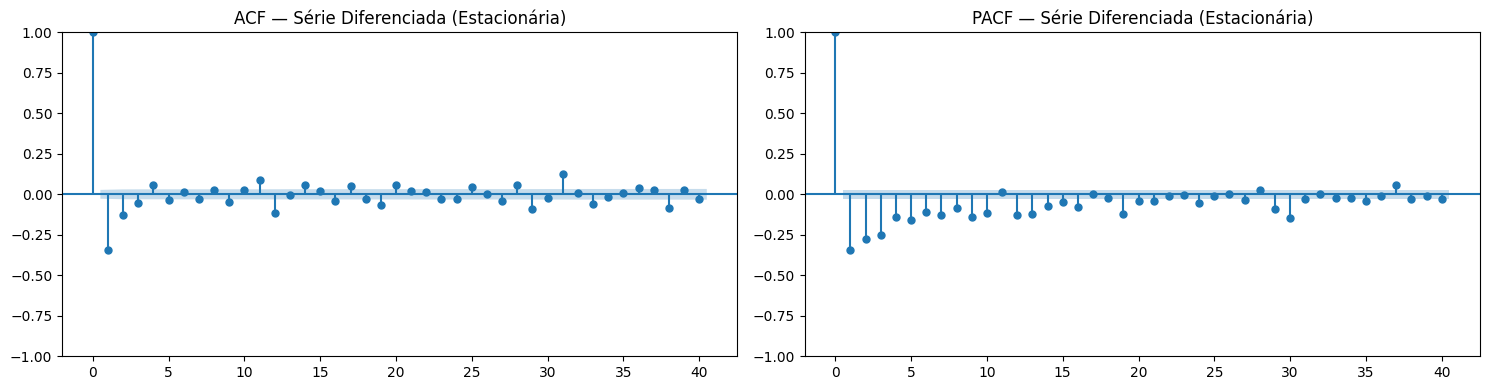

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie_diff, lags=40, ax=axes[0], title="ACF — Série Diferenciada (Estacionária)")
plot_pacf(serie_diff, lags=40, ax=axes[1], title="PACF — Série Diferenciada (Estacionária)")
plt.tight_layout()
plt.show()


### Divisão Cronológica entre Treino e Teste

Divide os dados mantendo a ordenação temporal (80% para treino e 20% para teste).


In [24]:
# Divisão temporal (80/20)
train_size = int(len(df_weekly) * 0.8)
treino = df_weekly[COLUNA_VALOR].iloc[:train_size]
teste = df_weekly[COLUNA_VALOR].iloc[train_size:]

print(f"Total de observações: {len(df_weekly)}")
print(f"Treino: {len(treino)} semanas (de {treino.index[0].date()} a {treino.index[-1].date()})")
print(f"Teste: {len(teste)} semanas (de {teste.index[0].date()} a {teste.index[-1].date()})")


Total de observações: 5131
Treino: 4104 semanas (de 1928-01-01 a 2006-08-20)
Teste: 1027 semanas (de 2006-08-27 a 2026-04-26)


### Modelagem de Referência (Base Models)

Calcula previsões simples (Média, Naive, Drift e Seasonal Naive) sobre o conjunto de teste para benchmarking.


### Treinamento e Otimização do Modelo SARIMA

Executa busca em grade (Grid Search) no conjunto de treino, obtém o melhor modelo por menor BIC e gera as previsões estáticas de teste.


Iniciando Grid Search do SARIMA...
Melhor por BIC: (1, 2, 2) x (0, 0, 1, 52) | BIC = 27915.08

--- Resumo Estatístico do Melhor Modelo SARIMA ---
                                      SARIMAX Results                                       
Dep. Variable:                                 High   No. Observations:                 4104
Model:             SARIMAX(1, 2, 2)x(0, 0, [1], 52)   Log Likelihood              -13936.776
Date:                              Thu, 21 May 2026   AIC                          27883.552
Time:                                      20:43:34   BIC                          27915.081
Sample:                                  01-01-1928   HQIC                         27894.721
                                       - 08-20-2006                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

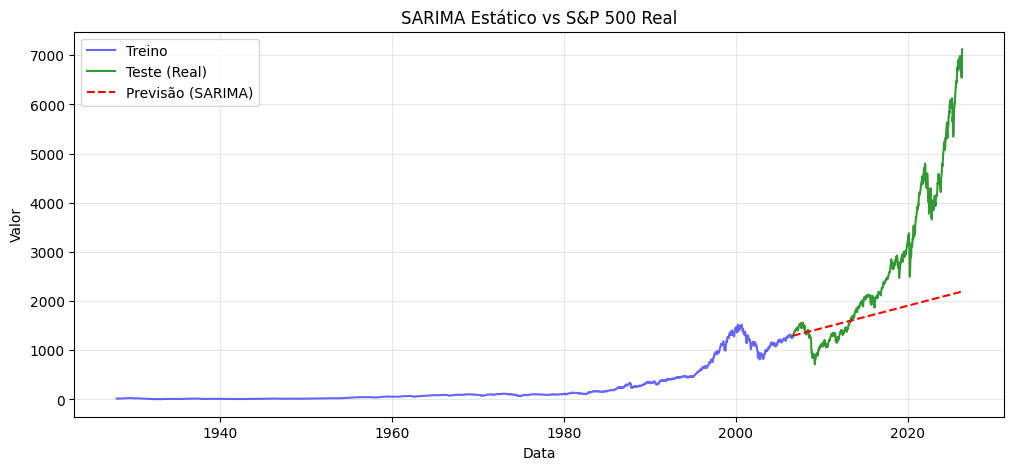

In [25]:
p_range = range(0, 3)     # AR
d_range = [ordem_diff]    # Diferenciação
q_range = range(0, 3)     # MA
P_range = range(0, 2)     # AR Sazonal
D_range = [0]             # Diferenciação Sazonal
Q_range = range(0, 2)     # MA Sazonal
m = 52                    # Sazonalidade semanal anual

print("Iniciando Grid Search do SARIMA...")
tabela_bic, melhor_modelo, melhor_ordem, melhor_seasonal = busca_melhor_sarima(
    treino, p_range, d_range, q_range, P_range, D_range, Q_range, m
)

print("\n--- Resumo Estatístico do Melhor Modelo SARIMA ---")
print(melhor_modelo.summary())

previsoes_sarima = melhor_modelo.forecast(steps=len(teste))
previsoes_sarima = pd.Series(previsoes_sarima, index=teste.index)

plota_previsoes(treino, teste, previsoes_sarima, titulo="SARIMA Estático vs S&P 500 Real")


### Diagnóstico dos Resíduos do SARIMA

Executa o diagnóstico gráfico e estatístico dos resíduos, aplicando o teste de Ljung-Box com ajuste correto de graus de liberdade.


In [ ]:
resultado_lb = diagnostica_residuos(melhor_modelo, melhor_ordem, melhor_seasonal, lags=20)


### Previsão com Rolling Forecast (Janela Móvel)

Executa a estratégia de Rolling Forecast sobre o teste reajustando os parâmetros mensalmente (step=4) e atualizando o modelo dinamicamente.


In [ ]:
previsoes_rolling = rolling_forecast_sarima(
    df_weekly[COLUNA_VALOR], 
    split_index=train_size, 
    order=melhor_ordem, 
    seasonal_order=melhor_seasonal, 
    step=4
)

plota_previsoes(treino, teste, previsoes_rolling, titulo="Rolling Forecast SARIMA vs S&P 500 Real")


### 13. Comparação das Métricas de Erro (MAE)

Compila o erro absoluto médio (MAE) de teste para todos os modelos estudados em uma tabela comparativa.
